**Nitheeswaran 24BAD079**

**Scenario 1**

In [1]:
#Importing libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

print("Dataset Snapshot:")
print(df.head(), "\n")

Dataset Snapshot:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40 



In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
inertia = []
sil_scores = []
K_range = range(2, 11)

In [5]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

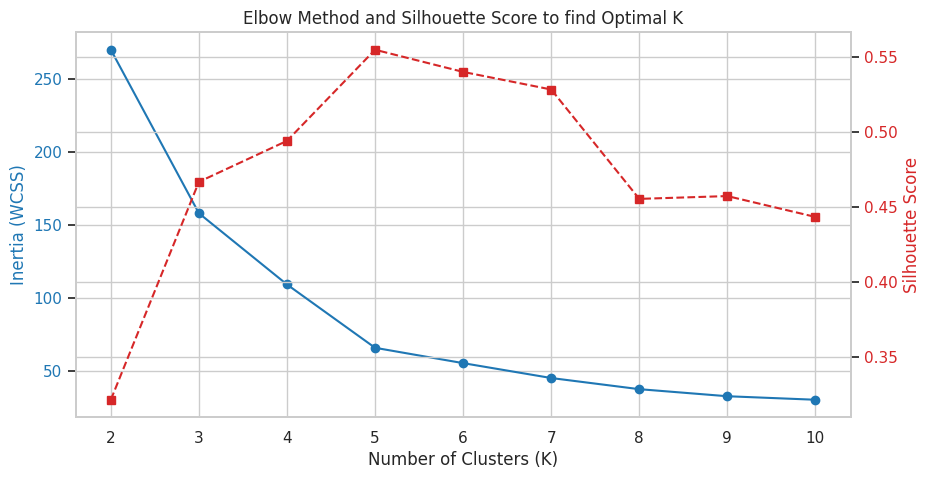

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(K_range, sil_scores, marker='s', color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method and Silhouette Score to find Optimal K')
plt.show()

In [7]:
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

cluster_labels = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = cluster_labels 

final_inertia = kmeans_final.inertia_
final_silhouette = silhouette_score(X_scaled, cluster_labels)

print(f"Optimal K chosen: {optimal_k}")
print(f"Final Inertia (WCSS): {final_inertia:.2f}")
print(f"Final Silhouette Score: {final_silhouette:.4f}\n")

Optimal K chosen: 5
Final Inertia (WCSS): 65.57
Final Silhouette Score: 0.5547



<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

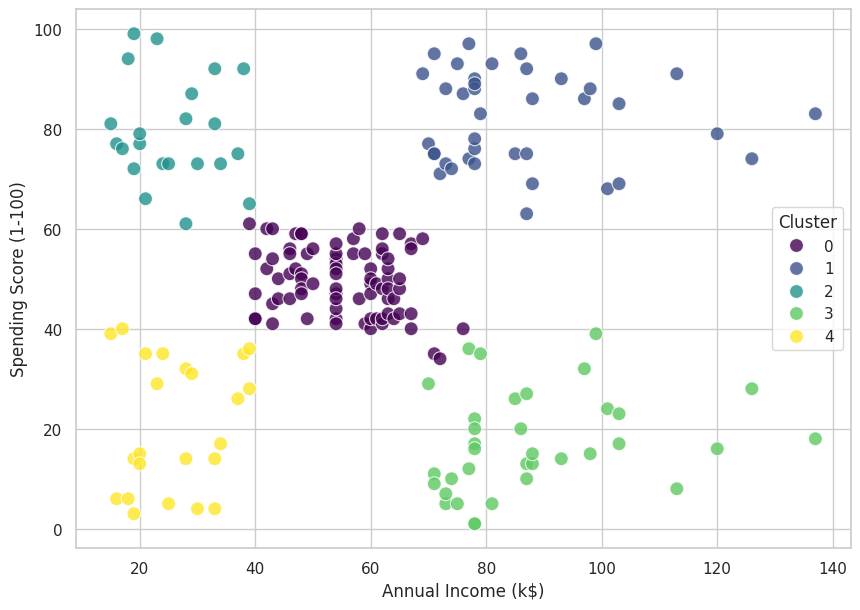

In [8]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=df['Annual Income (k$)'], 
    y=df['Spending Score (1-100)'], 
    hue=df['Cluster'], 
    palette='viridis', 
    s=100, 
    alpha=0.8
)

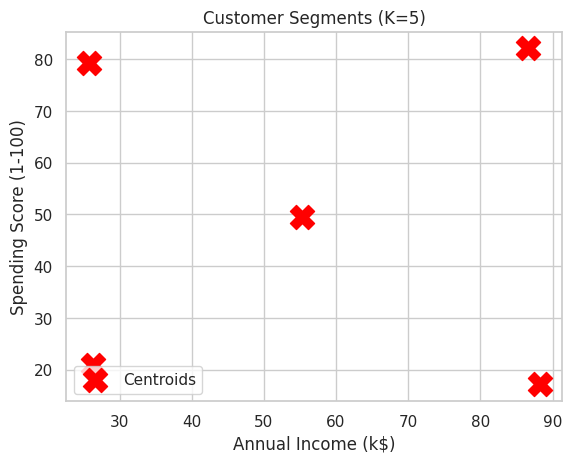

Nitheeswaran M 24BAD079


In [9]:
centroids_original_scale = scaler.inverse_transform(kmeans_final.cluster_centers_)

plt.scatter(
    centroids_original_scale[:, 0], 
    centroids_original_scale[:, 1], 
    s=300, 
    c='red', 
    marker='X', 
    label='Centroids'
)

plt.title('Customer Segments (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()
print("Nitheeswaran M 24BAD079")

**Scenario 2**

In [10]:
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
df = df.dropna() 

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
n_components_range = range(2, 11)
aic_scores = []
bic_scores = []

for n in n_components_range:
    gmm_temp = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm_temp.fit(X_scaled)
    aic_scores.append(gmm_temp.aic(X_scaled))
    bic_scores.append(gmm_temp.bic(X_scaled))

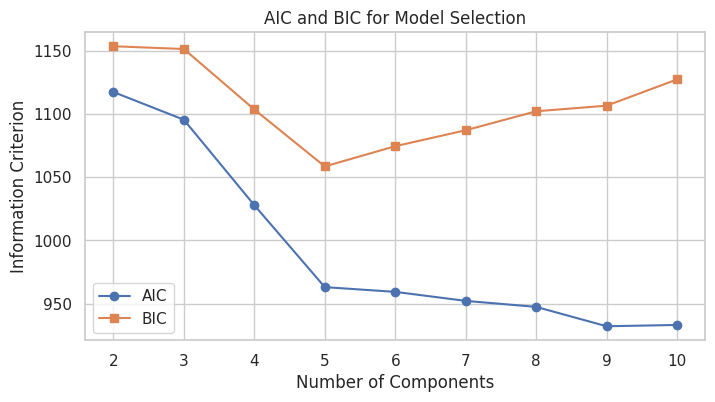

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(n_components_range, aic_scores, label='AIC', marker='o')
plt.plot(n_components_range, bic_scores, label='BIC', marker='s')
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.title('AIC and BIC for Model Selection')
plt.legend()
plt.show()

In [14]:
optimal_k = 5 
gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

GaussianMixture(n_components=5, random_state=42)

In [15]:
probabilities = gmm.predict_proba(X_scaled) 

gmm_labels = gmm.predict(X_scaled)
df['GMM_Cluster'] = gmm_labels
df['Max_Probability'] = probabilities.max(axis=1)

In [16]:
log_likelihood = gmm.score(X_scaled) * len(X_scaled) # Total log-likelihood
aic = gmm.aic(X_scaled)
bic = gmm.bic(X_scaled)
sil_score_gmm = silhouette_score(X_scaled, gmm_labels)

print("GMM EVALUATION METRICS")
print(f"Log-Likelihood: {log_likelihood:.2f}")
print(f"AIC: {aic:.2f}")
print(f"BIC: {bic:.2f}")
print(f"Silhouette Score: {sil_score_gmm:.4f}\n")

GMM EVALUATION METRICS
Log-Likelihood: -452.50
AIC: 963.00
BIC: 1058.65
Silhouette Score: 0.5537



In [17]:
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

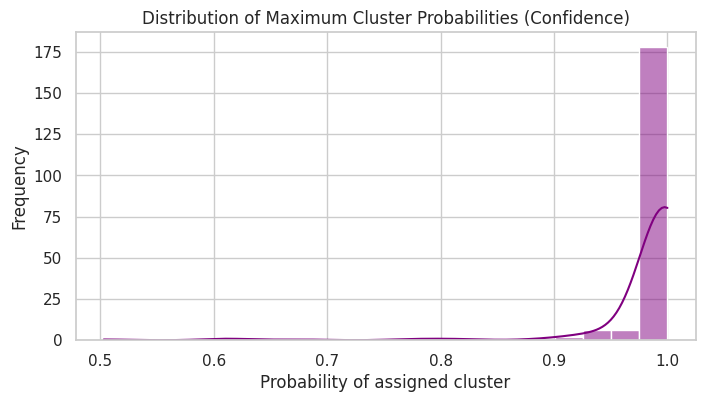

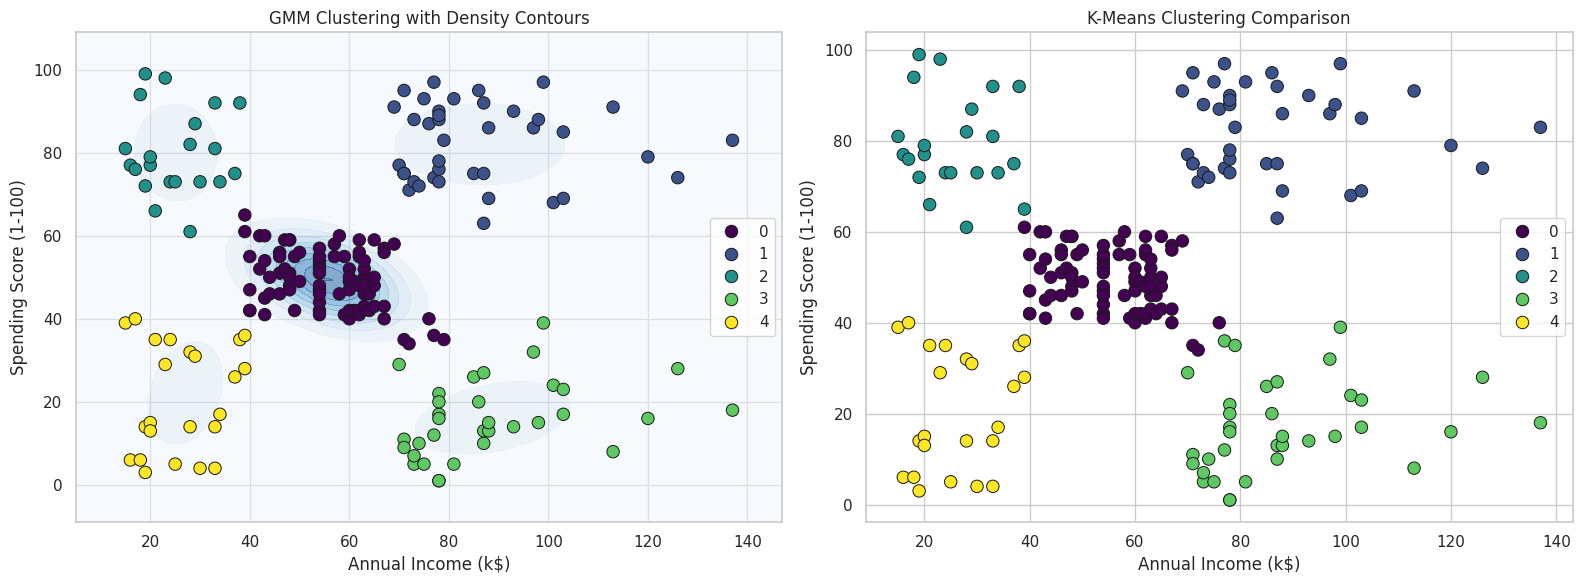

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Max_Probability'], bins=20, kde=True, color='purple')
plt.title('Distribution of Maximum Cluster Probabilities (Confidence)')
plt.xlabel('Probability of assigned cluster')
plt.ylabel('Frequency')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_min, x_max = X.iloc[:, 0].min() - 10, X.iloc[:, 0].max() + 10
y_min, y_max = X.iloc[:, 1].min() - 10, X.iloc[:, 1].max() + 10
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_data = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid_data)
Z = np.exp(gmm.score_samples(grid_scaled)).reshape(xx.shape) 

axes[0].contourf(xx, yy, Z, levels=10, cmap='Blues', alpha=0.5)
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=gmm_labels, palette='viridis', 
                s=80, edgecolor='k', ax=axes[0], legend='full')
axes[0].set_title('GMM Clustering with Density Contours')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=kmeans_labels, palette='viridis', 
                s=80, edgecolor='k', ax=axes[1], legend='full')
axes[1].set_title('K-Means Clustering Comparison')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()
print("Nitheeswaran M 24BAD079")